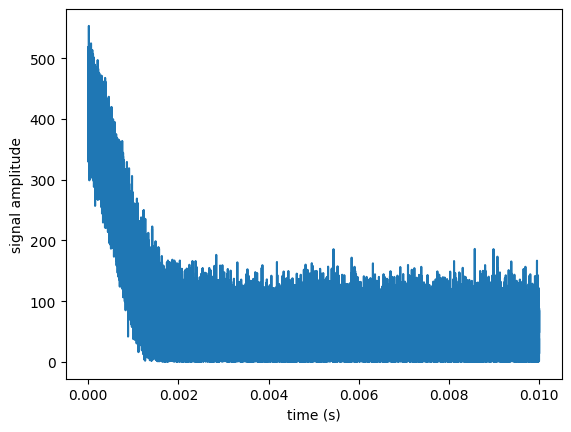

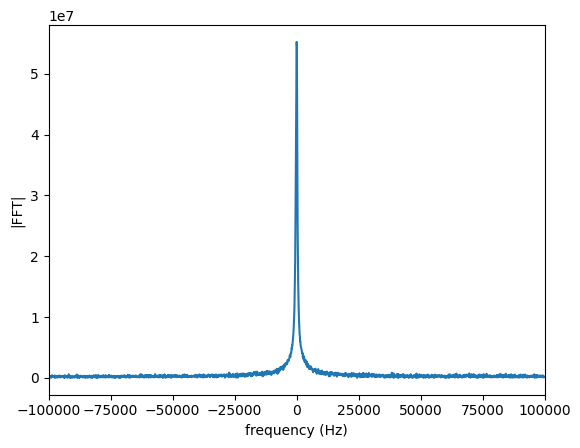

peak frequency =  0.00 Hz
FFT bin size = 100.00 Hz


In [44]:
#PLOT A SINGLE FID

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load the data
folder = Path("C:/Users/Suber/Desktop/400ShuttlerData/20260718_FID_v2")
file = next(folder.glob("*.npz"))   # Gets the first .npz file
data = np.load(file)

time = 16 * data["time"] #16 for decimation factor
signal = data["signal"] #Complex-valued array

# Plot signal amplitude vs time
plt.figure()
plt.plot(time, np.abs(signal))
plt.xlabel("time (s)")
plt.ylabel("signal amplitude")
plt.show()

# Compute FFT
dt = time[1] - time[0]           
N = len(signal)

fft_signal = np.fft.fft(signal)
freq = np.fft.fftfreq(N, d=dt)

# Shift zero frequency to center
fft_signal = np.fft.fftshift(fft_signal)
freq = np.fft.fftshift(freq)

# Plot FFT magnitude
plt.figure()
plt.plot(freq, np.abs(fft_signal))
plt.xlim(-1e5, 1e5)
plt.xlabel("frequency (Hz)")
plt.ylabel("|FFT|")
plt.show()

# Find peak
peak_idx = np.argmax(np.abs(fft_signal))
peak_freq = freq[peak_idx]
# peak_amp = np.abs(fft_signal[peak_idx])
print(f"peak frequency =  {peak_freq:.2f} Hz")
# print(f"Peak amplitude: {peak_amp:.3e}")

bin_size = 1 / time[-1]
print(f"FFT bin size = {bin_size:.2f} Hz")

Processing 2026-07-17-155213_Data.npz
Processing 2026-07-17-160005_Data.npz
Processing 2026-07-17-160756_Data.npz
Processing 2026-07-17-161548_Data.npz
Processing 2026-07-17-162340_Data.npz
Processing 2026-07-17-163133_Data.npz
Processing 2026-07-17-163926_Data.npz
Processing 2026-07-17-164720_Data.npz
Processing 2026-07-17-165514_Data.npz
Processing 2026-07-17-170308_Data.npz
Processing 2026-07-17-171102_Data.npz


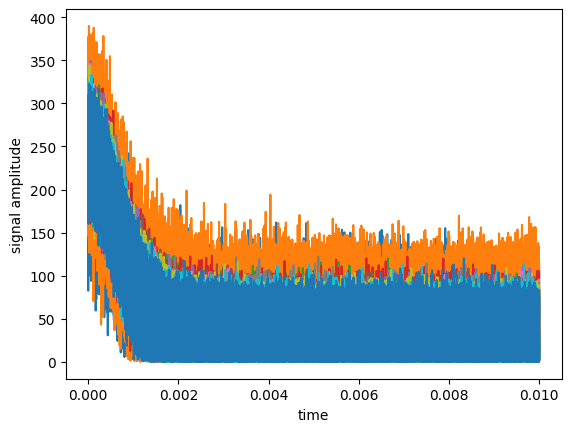

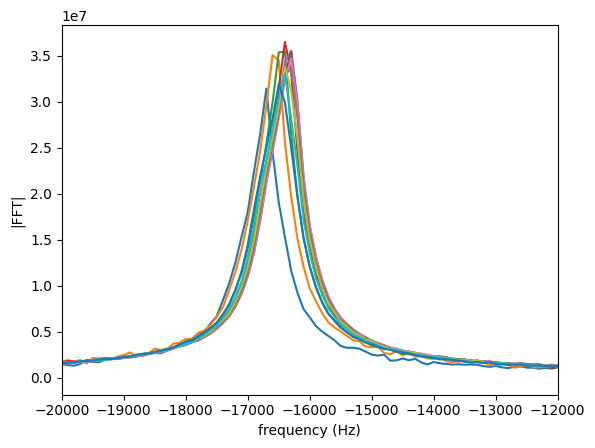

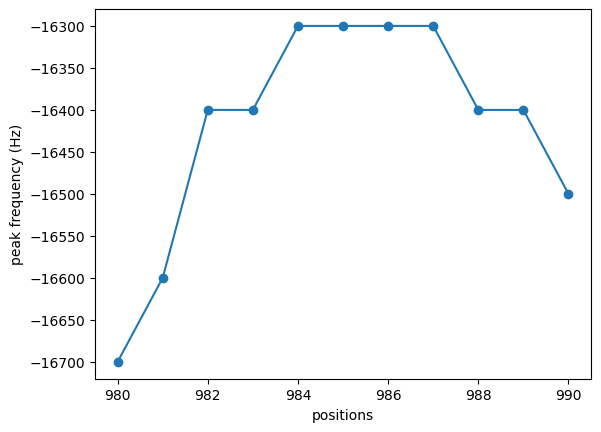

In [45]:
# PLOT MANY FIDS

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Folder containing the data
data_folder = Path("C:/Users/Suber/Desktop/400ShuttlerData/20260716_FIDs_v6")

# Find all *_Data.npz files and sort them chronologically
files = sorted(data_folder.glob("*_Data.npz"))

positions = np.arange(980,991,1)

peak_freqs = []

plt.figure(1)

plt.figure(2)

for file in files:
    print(f"Processing {file.name}")

    data = np.load(file)

    time = 16 * data["time"] #16 for decimation factor
    signal = data["signal"]
    
    plt.figure(1)
    plt.plot(time, np.abs(signal))

    dt = time[1] - time[0]
    N = len(signal)

    fft_signal = np.fft.fft(signal)
    freq = np.fft.fftfreq(N, d=dt)

    fft_signal = np.fft.fftshift(fft_signal)
    freq = np.fft.fftshift(freq)
    
    plt.figure(2)
    plt.plot(freq, np.abs(fft_signal))

    peak_idx = np.argmax(np.abs(fft_signal))
    peak_freqs.append(freq[peak_idx])

plt.figure(1)
plt.xlabel("time")
plt.ylabel("signal amplitude")
    
plt.figure(2)
plt.xlim(-20000, -12000)
plt.xlabel("frequency (Hz)")
plt.ylabel("|FFT|")

plt.figure()
plt.plot(positions, peak_freqs, 'o-')
plt.xlabel("positions")
plt.ylabel("peak frequency (Hz)")
plt.show()

Processing 2026-07-20-172418_Data.npz
Processing 2026-07-20-173211_Data.npz
Processing 2026-07-20-174004_Data.npz
Processing 2026-07-20-174758_Data.npz
Processing 2026-07-20-175551_Data.npz
Processing 2026-07-20-180344_Data.npz
Processing 2026-07-20-181138_Data.npz
Processing 2026-07-20-181931_Data.npz
Processing 2026-07-20-182724_Data.npz
Processing 2026-07-20-183518_Data.npz
Processing 2026-07-20-184311_Data.npz
Processing 2026-07-20-185104_Data.npz
Processing 2026-07-20-185858_Data.npz
Processing 2026-07-20-190651_Data.npz
Processing 2026-07-20-191444_Data.npz
Processing 2026-07-20-192238_Data.npz
Processing 2026-07-20-193031_Data.npz
Processing 2026-07-20-193825_Data.npz
Processing 2026-07-20-194618_Data.npz


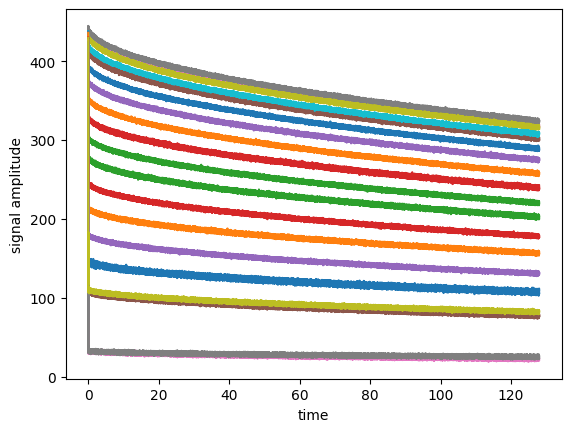

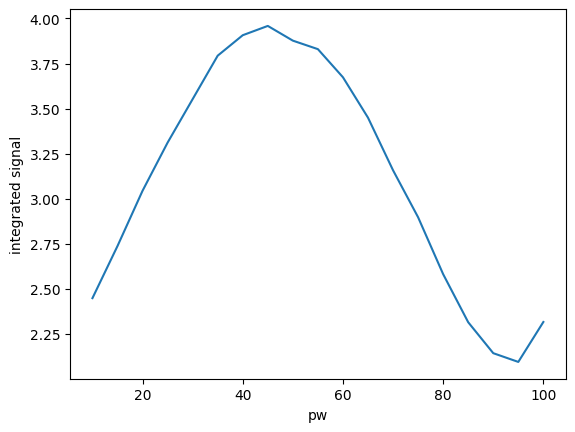

max signal with pw = 45.00


In [63]:
# ANALYZE RABI DATA

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Folder containing the data
data_folder = Path("C:/Users/Suber/Desktop/400ShuttlerData/20260721_SpinLockRabi")

# Find all *_Data.npz files and sort them chronologically
files = sorted(data_folder.glob("*_Data.npz"))

pw = np.arange(10,105,5)

integrated_sig = []

plt.figure(1)

for file in files:
    print(f"Processing {file.name}")

    data = np.load(file)

    time = 16 * data["time"] #16 for decimation factor
    signal = data["signal"]
        
    plt.figure(1)
    plt.plot(time, np.abs(signal))
    
    mask = (time >= 10e-3) & (time <= 20e-3)
    integral = np.trapz(np.abs(signal[mask]), time[mask])
    integrated_sig.append(integral)

integrated_sig = np.array(integrated_sig)

plt.figure(1)
plt.xlabel("time")
plt.ylabel("signal amplitude")

plt.figure()
plt.plot(pw, integrated_sig)
plt.xlabel("pw")
plt.ylabel("integrated signal")
plt.show()

peak_idx = np.argmax(integrated_sig)
peak_pw = pw[peak_idx]
print(f"max signal with pw = {peak_pw:.2f}")